# Creation and visualization of stripe shapes

This notebook walks through the primitives in
`metashapes.shape.primitives.stripes`: **`Bar`**. It's a special kind of
shape -- infinite along one axis, so it only ever makes sense inside a
`UnitCell` (there's no finite bounding box to look at on its own). For it,
we:

1. construct it and place it in a `UnitCell`,
2. look at its parametric (serializable) representation,
3. sample the cell's periodic SDF,
4. rasterize it into a binary mask,
5. look at the Shapely geometry `UnitCell.to_shapely()` gives us, and
6. compare that geometry's raster against the SDF mask to see they agree
   almost everywhere.

`Bar` also can't be rotated (`Bar.rotate()` raises -- a bar only tiles
correctly when its axis is a lattice direction), so instead we look at its
two `axis` modes, `'x'` and `'y'`, which behave like genuinely different
shapes rather than two values of a continuous parameter.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Bar
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell
from metashapes.adapters.shapely.raster import shapely_to_numpy

dtype = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Shapes live in a `UnitCell`

A `Shape` on its own lives in infinite, continuous space -- it knows nothing
about periodicity. A `UnitCell` pairs a `Shape` (the "scene") with a
`Lattice`, and turns the shape's SDF into a *periodic* SDF by taking the
minimum over neighboring lattice copies. This matters even more for `Bar`
than for a finite shape: a bar is already infinite along its own axis, and
it's the lattice that gives its *other* direction a period. Below, one
horizontal bar is tiled 1x3 to make that periodicity visible along the
direction it's actually bounded in.

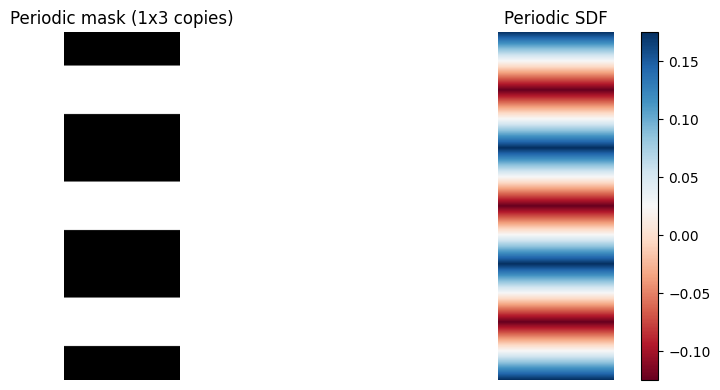

In [13]:
lattice = Lattice.rectangular(1.0, 0.6).to(dtype=dtype, device=device)

demo = Bar(offset=0.3, width=0.25, axis='x')
demo = demo.to(dtype=dtype, device=device)
demo_cell = UnitCell(lattice=lattice, scene=demo)

nx = ny = 256
mask = demo_cell.mask(nx, ny, cartesian=True, repeat=(1, 3))
sdf_periodic = demo_cell.rasterize(nx, ny, cartesian=True, repeat=(1, 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mask.cpu().detach(), origin='lower', cmap='gray')
axes[0].set_title('Periodic mask (1x3 copies)')
im = axes[1].imshow(sdf_periodic.cpu().detach(), origin='lower', cmap='RdBu')
axes[1].set_title('Periodic SDF')
plt.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.axis('off')
fig.tight_layout()
plt.show()

## Two views of a shape: parametric and Shapely

Before getting to SDF/mask comparisons, it's worth looking at a shape two
other ways:

- **`shape.to_parametric()`** -- the plain dict of constructor arguments
  `Shape` serialization uses (see `metashapes.adapters.yaml`). This is the
  most direct way to see exactly what values a shape actually holds.
- **`UnitCell.to_shapely()`** -- the cell's scene as a Shapely geometry,
  wrapped periodically into the cell. Displayed directly (not rasterized),
  Jupyter renders it as a vector image via Shapely's own SVG repr, which is
  a nice complement to the raster masks below.

In [3]:
def show_parametric(shape, ndigits=4):
    """Pretty-print shape.to_parametric(), rounded for readability."""
    def _round(v):
        if isinstance(v, float):
            return round(v, ndigits)
        if isinstance(v, list):
            return [_round(x) for x in v]
        if isinstance(v, dict):
            return {k: _round(x) for k, x in v.items()}
        return v
    data = _round(shape.to_parametric())
    return data

## Inspecting a single cell: SDF, mask, and Shapely agreement

`show_cell()` below is the same helper used in the quadrilaterals notebook.
Given a `UnitCell`, it:

- samples the cell's periodic SDF and hard mask via `rasterize()`/`mask()`,
- converts the *same* cell to Shapely via `UnitCell.to_shapely()` (which
  wraps the scene periodically into the cell, matching what `mask()`
  represents -- not `shape_to_shapely()` on the bare shape, which knows
  nothing about the lattice),
- rasterizes that Shapely polygon onto the exact grid `rasterize()` used
  internally, via `shapely_to_numpy()`, and
- reports where the two masks disagree.

`cell.extent()` (and hence this whole comparison) only depends on the
lattice, not on the scene's own `bounds()` -- so this works unmodified even
though `Bar.bounds()` is infinite along its own axis. The two masks won't
agree at literally every pixel -- the SDF and Shapely rasterize a boundary
very slightly differently -- but the agreement should be well above 99%; a
much lower number would mean something is actually wrong.

In [4]:
def show_cell(cell, title=None, nx=256, ny=256):
    """Plot a UnitCell's SDF, the hard mask derived from it, the mask from
    UnitCell.to_shapely(), and where the two masks disagree. Single cell
    (repeat=(1, 1)), since to_shapely() itself represents exactly one cell.
    """
    xmin, xmax, ymin, ymax = cell.extent()

    sdf = cell.rasterize(nx, ny, cartesian=True).detach().cpu().numpy()
    mask_sdf = cell.mask(nx, ny, cartesian=True).detach().cpu().numpy().astype(bool)

    # Same grid rasterize(cartesian=True) builds internally, so the Shapely
    # mask below is compared pixel-for-pixel against the same sample points.
    fx = torch.arange(nx, dtype=dtype, device=device) / nx
    fy = torch.arange(ny, dtype=dtype, device=device) / ny
    xs = xmin + fx * (xmax - xmin)
    ys = ymin + fy * (ymax - ymin)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    Xn, Yn = X.detach().cpu().numpy(), Y.detach().cpu().numpy()

    geom = cell.to_shapely()
    mask_shapely = shapely_to_numpy(geom, Xn, Yn)

    mismatch = mask_sdf != mask_shapely
    agreement = 100.0 * (1.0 - mismatch.mean())

    extent = [xmin, xmax, ymin, ymax]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    im0 = axes[0].imshow(sdf, origin="lower", extent=extent, cmap="RdBu")
    axes[0].contour(Xn, Yn, sdf, levels=[0.0], colors="k", linewidths=1.2)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    axes[0].set_title("SDF")

    axes[1].imshow(mask_sdf, origin="lower", extent=extent, cmap="gray")
    axes[1].set_title("Mask from SDF\n(UnitCell.mask())")

    axes[2].imshow(mask_shapely, origin="lower", extent=extent, cmap="gray")
    axes[2].set_title("Mask from Shapely\n(UnitCell.to_shapely())")

    axes[3].imshow(mismatch, origin="lower", extent=extent, cmap="Reds")
    axes[3].set_title(f"Mismatch\n({agreement:.3f}% agree)")

    for ax in axes:
        ax.set_aspect("equal")
        ax.axis("off")

    fig.suptitle(title or type(cell.scene).__name__, fontsize=14, y=1.03)
    fig.tight_layout()
    plt.show()

    label = title or type(cell.scene).__name__
    print(f"{label}: mask/Shapely agreement = {agreement:.3f}% "
          f"({mismatch.sum()} / {mismatch.size} pixels differ)")

## `Bar`, `axis='x'`

Parameters: `offset` (position of the bar's centreline along the
*perpendicular* axis), `width` (full thickness, must be positive), and
`axis`. With `axis='x'` the bar runs along x and is bounded in y.

In [14]:
bar_x = Bar(offset=0.3, width=0.3, axis='x')
bar_x = bar_x.to(dtype=dtype, device=device)
bar_x_cell = UnitCell(lattice=lattice, scene=bar_x)

In [15]:
show_parametric(bar_x)

{'type': 'Bar', 'offset': 0.3, 'width': 0.3, 'axis': 'x'}

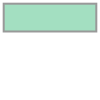

In [16]:
bar_x_cell.to_shapely()

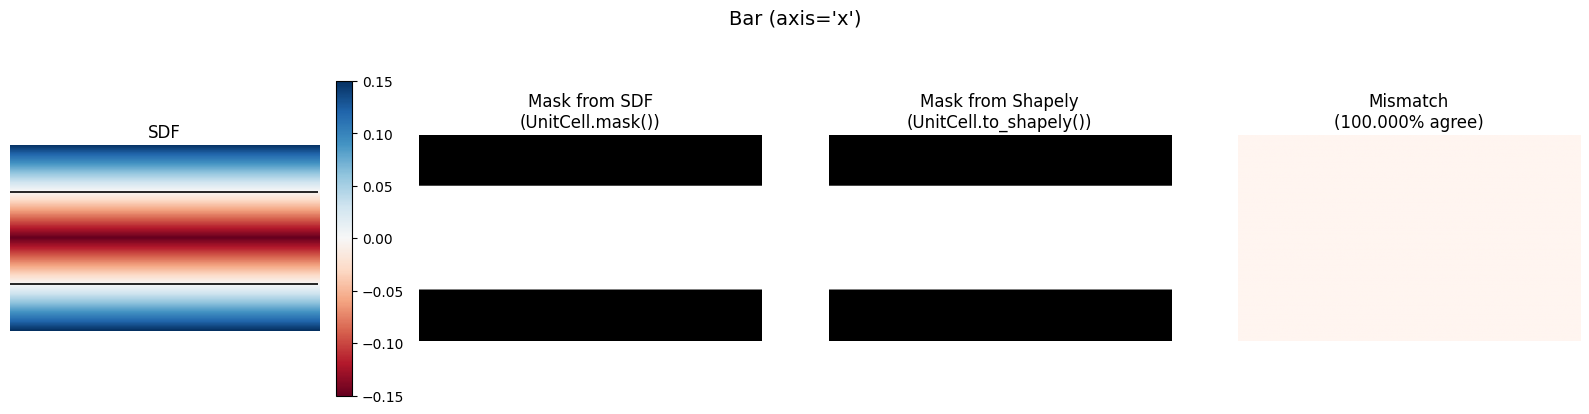

Bar (axis='x'): mask/Shapely agreement = 100.000% (0 / 65536 pixels differ)


In [17]:
show_cell(bar_x_cell, title="Bar (axis='x')")

## `Bar`, `axis='y'`

With `axis='y'` the roles swap: the bar runs along y and is bounded in x.
`Bar` can't be rotated to get from one orientation to the other (a bar only
tiles correctly when its axis is a lattice direction) -- `axis` has to be
chosen at construction time instead.

In [19]:
bar_y = Bar(offset=-0.5, width=0.3, axis='y')
bar_y = bar_y.to(dtype=dtype, device=device)
bar_y_cell = UnitCell(lattice=lattice, scene=bar_y)

In [20]:
show_parametric(bar_y)

{'type': 'Bar', 'offset': -0.5, 'width': 0.3, 'axis': 'y'}

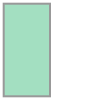

In [21]:
bar_y_cell.to_shapely()

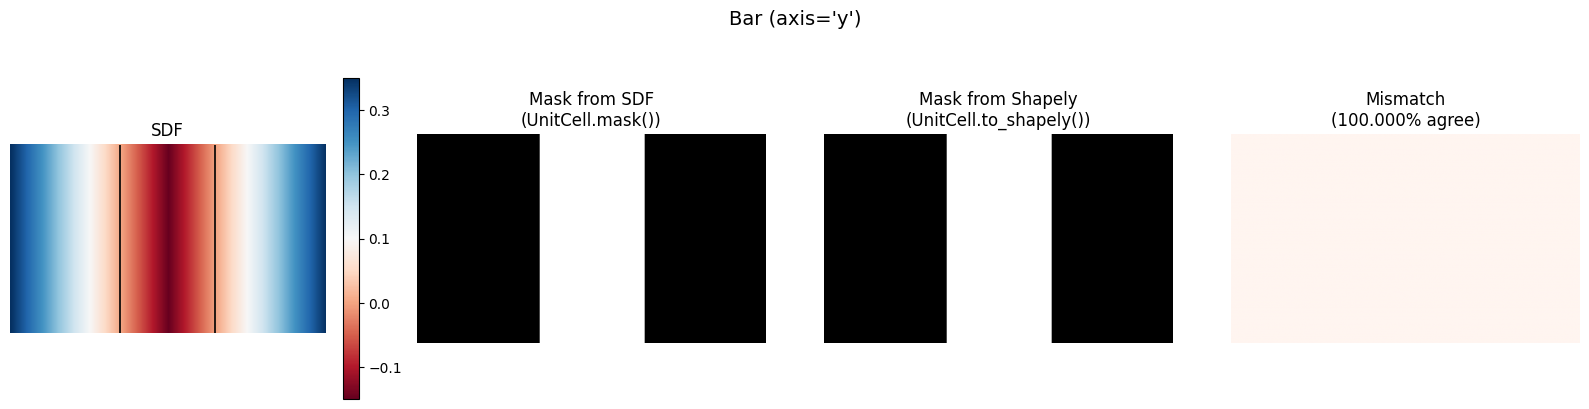

Bar (axis='y'): mask/Shapely agreement = 100.000% (0 / 65536 pixels differ)


In [22]:
show_cell(bar_y_cell, title="Bar (axis='y')")